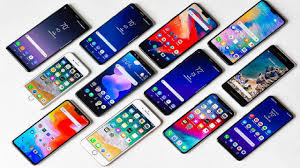


**تحلیل اگهی های موبایل در پلتفرم دیوار**


> **تحلیل کدام موبایل قیمت بیشتری دارد؟.**


> **کدام بیشترین تعداد اگهی فروش را داشته؟**

---



In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
#اماده کردن فایل ...

!pip install pandas

#import libraries
import pandas as pd

file_path = "/content/drive/My Drive/data.csv"

mobile_data = pandas.read_csv(file_path)

mobile_data

,title,price,url
0,ایفون 17پرومکس طرح اصلی,95000000,https://divar.ir/v/ایفون-17پرومکس-طرح-اصلی/gap...
1,گوشی شیاومی m4pro 256 ram 8 معاوضه,210000000,https://divar.ir/v/گوشی-شیاومی-m4pro-256-ram-8...
2,سامسونگs23الترا,1380000000,https://divar.ir/v/سامسونگs23الترا/gav4_4s0
3,گوشی سامسونگ m32 ۱۲۸g,150000000,https://divar.ir/v/گوشی-سامسونگ-m32-۱۲۸g/gav8vByS
4,طرح سامسونگ s24ultra/قلم فعال+دوربین 48 مگاپیکسل,59800000,https://divar.ir/v/طرح-سامسونگ-s24ultra-قلم-فع...
5,سامسونگ b315e دوسیم کارت رمخور فاقد دوربین,23000000,https://divar.ir/v/سامسونگ-b315e-دوسیم-کارت-رم...
6,S25 ultra آکبند ریجستر شده,2370000000,https://divar.ir/v/s25-ultra-آکبند-ریجستر-شده/...
7,خرید و فروش اقساط اپل 12 13 14 15 17 iPhone 16,1650000000,https://divar.ir/v/خرید-و-فروش-اقساط-اپل-12-13...
8,گوشی پوکو poco x6 pro,420000000,https://divar.ir/v/گوشی-پوکو-poco-x6-pro/gav4P-q4
9,شیائومی پوکو poco X7 pro حافظه 512 رم12,710000000,https://divar.ir/v/شیائومی-پوکو-poco-x7-pro-حا...


*`بدست آوردن قیمت موبایل های مختلف`*
### *کدام موبایل اگهی بیشتری را داشته؟*



In [19]:
import re

def extract_brand(title):
    title = title.lower() # Convert to lowercase for case-insensitive matching
    brands = {
        'ایفون': 'iPhone',
        'آیفون': 'iPhone',
        'سامسونگ': 'Samsung',
        'شیاومی': 'Xiaomi',
        'شیائومی': 'Xiaomi',
        'پوکو': 'Poco',
        'هواوی': 'Huawei',
        'ردمی': 'Redmi'
    }

    for keyword, brand_name in brands.items():
        if re.search(r'\b' + re.escape(keyword) + r'\b', title):
            return brand_name
    return 'Other'

# Apply the function to create a new 'brand' column
mobile_data['brand'] = mobile_data['title'].apply(extract_brand)

# Count the occurrences of each brand
brand_counts = mobile_data['brand'].value_counts()

print("تعداد آگهی‌های هر برند:")
print(brand_counts)


تعداد آگهی‌های هر برند:
brand
Other      10
Xiaomi      4
Samsung     4
iPhone      3
Poco        1
Huawei      1
Redmi       1
Name: count, dtype: int64


/tmp/ipykernel_2722/1458785990.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.index, y=brand_counts.values, palette='viridis')


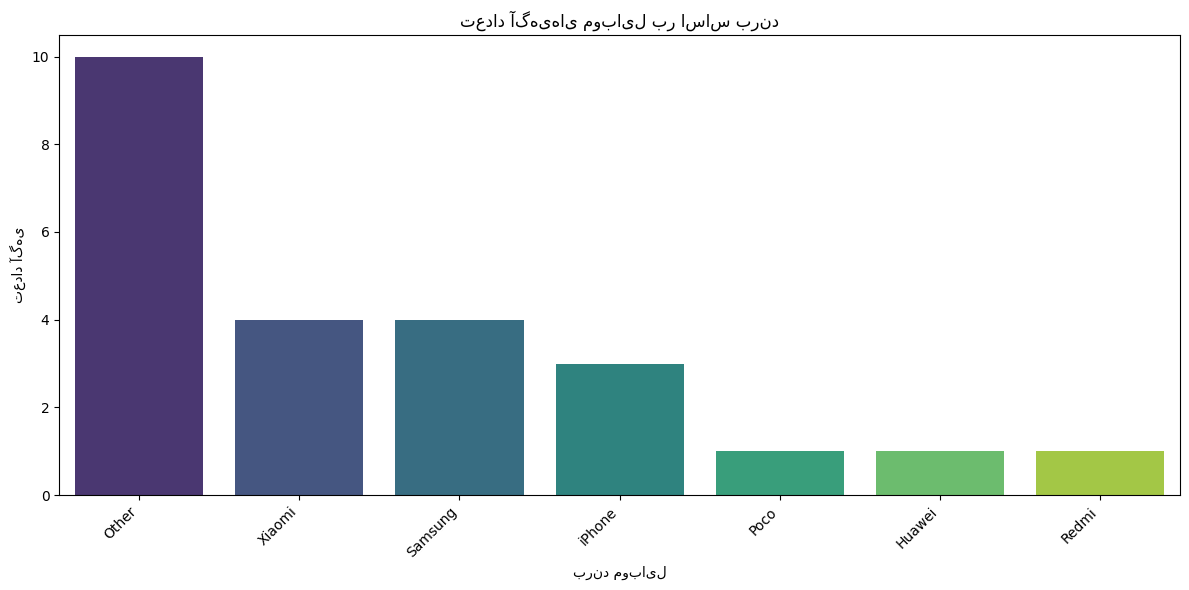

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for brand counts
plt.figure(figsize=(12, 6))
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette='viridis')
plt.title('تعداد آگهی‌های موبایل بر اساس برند')
plt.xlabel('برند موبایل')
plt.ylabel('تعداد آگهی')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('brand_counts_bar_plot.png') # Save the plot
plt.show()


## **کدام برند موبایل قیمت بیشتری داشته؟**

In [24]:
# Convert 'price' column to numeric, handling non-numeric values
mobile_data['price'] = pd.to_numeric(mobile_data['price'], errors='coerce')

# Drop rows where price is NaN after conversion
mobile_data.dropna(subset=['price'], inplace=True)

# Calculate the average price for each brand
average_prices = mobile_data.groupby('brand')['price'].mean().sort_values(ascending=False)

print("میانگین قیمت آگهی‌های موبایل بر اساس برند:")
print(average_prices)


میانگین قیمت آگهی‌های موبایل بر اساس برند:
brand
Other      1.043800e+09
Poco       4.200000e+08
Xiaomi     2.975025e+08
Redmi      1.950000e+08
iPhone     1.580000e+08
Huawei     9.500000e+07
Samsung    7.320000e+07
Name: price, dtype: float64


/tmp/ipykernel_2722/2538926871.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_prices.index, y=average_prices.values, palette='plasma')


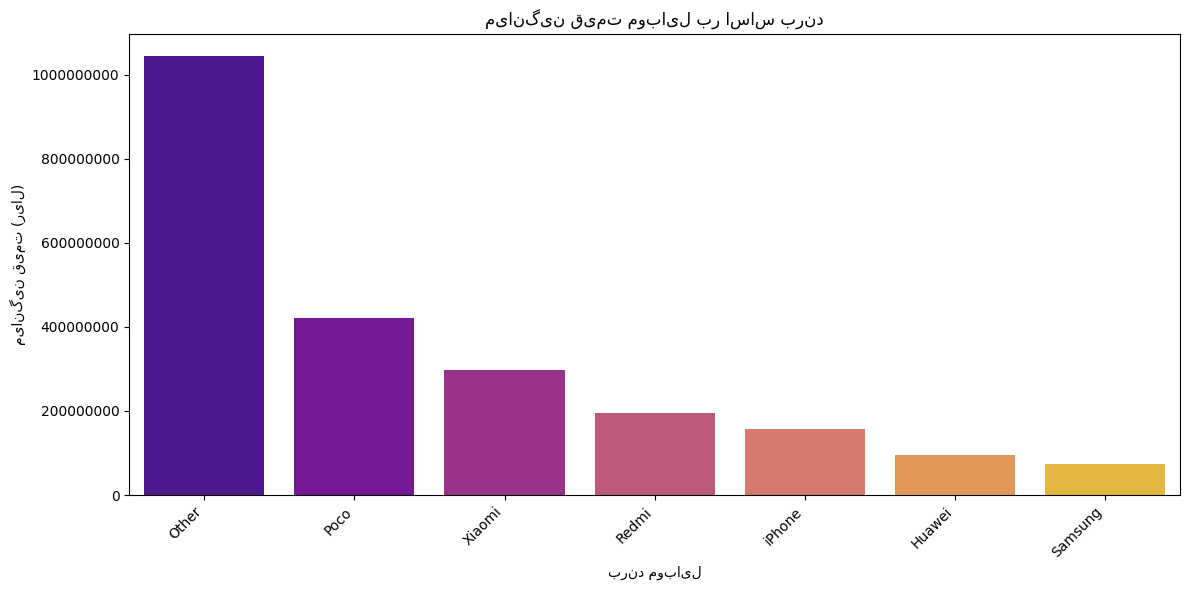

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for average prices
plt.figure(figsize=(12, 6))
sns.barplot(x=average_prices.index, y=average_prices.values, palette='plasma')
plt.title('میانگین قیمت موبایل بر اساس برند')
plt.xlabel('برند موبایل')
plt.ylabel('میانگین قیمت (ریال)')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.tight_layout()
plt.savefig('average_prices_bar_plot.png') # Save the plot
plt.show()
